In [18]:
import os
import pathlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil
import random
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D, Activation, GlobalMaxPool2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras import Input, Model
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
import splitfolders

In [20]:
splitfolders.ratio(r"C:\Users\Ajay\Desktop\Inno_Projects\Kavi Dharshini\dataset", output="output",
    seed=1337, ratio=(.75, .2, .05), group_prefix=None, move=False)

Copying files: 674 files [00:00, 702.61 files/s]


In [21]:
data_dir = pathlib.Path('output/')
train_dir = 'output/train'
val_dir = 'output/val'
test_dir = 'output/test'

In [22]:
class_name = np.array(sorted([item.name for item in data_dir.glob("*")]))
print(class_name)

['test' 'train' 'val']


In [23]:
for dirpath, dirnames, filenames in os.walk('output'):
  print(f"{len(dirnames)} folder and {len(filenames)} images in {dirpath}")

3 folder and 0 images in output
7 folder and 0 images in output\test
0 folder and 7 images in output\test\5_miles_speedlimit
0 folder and 8 images in output\test\No_Cars Allowed
0 folder and 4 images in output\test\No_entry
0 folder and 7 images in output\test\No_horn
0 folder and 8 images in output\test\No_Left_Turn
0 folder and 2 images in output\test\No_right_turn
0 folder and 2 images in output\test\speedlimit_15
7 folder and 0 images in output\train
0 folder and 88 images in output\train\5_miles_speedlimit
0 folder and 106 images in output\train\No_Cars Allowed
0 folder and 52 images in output\train\No_entry
0 folder and 97 images in output\train\No_horn
0 folder and 103 images in output\train\No_Left_Turn
0 folder and 27 images in output\train\No_right_turn
0 folder and 30 images in output\train\speedlimit_15
7 folder and 0 images in output\val
0 folder and 23 images in output\val\5_miles_speedlimit
0 folder and 28 images in output\val\No_Cars Allowed
0 folder and 14 images in ou

In [24]:
def view_random_image(target_dir, target_class):
    target_folder = target_dir + target_class
    random_image = random.sample(os.listdir(target_folder), 1)
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image Shape : {img.shape}")
    plt.show()

Image Shape : (69, 80, 3)


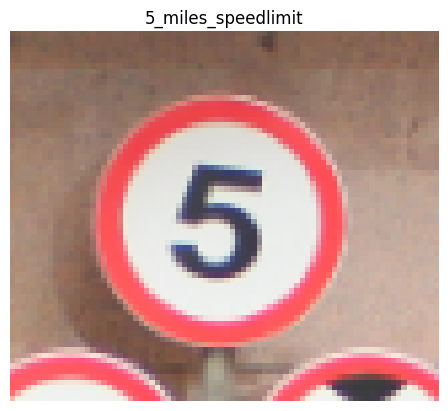

In [25]:
for i in range(1,2):
    img_n = view_random_image(target_dir='output/train/', target_class='5_miles_speedlimit')

Image Shape : (101, 92, 3)


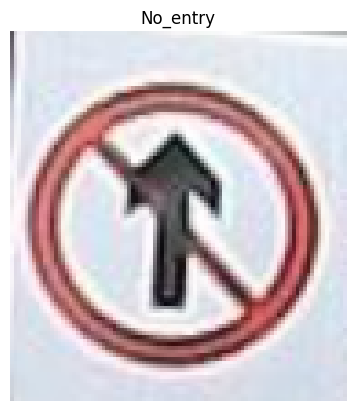

In [26]:
for i in range(1,2):
    img_n = view_random_image(target_dir='output/train/', target_class='No_entry')

Image Shape : (78, 87, 3)


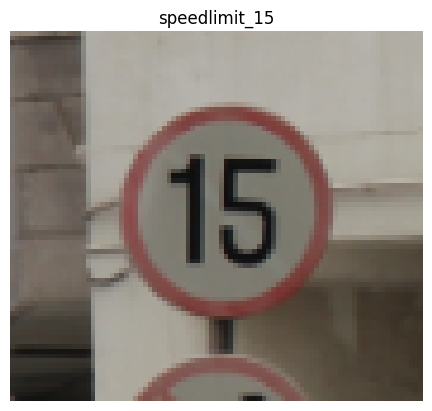

In [27]:
for i in range(1,2):
    img_n = view_random_image(target_dir='output/train/', target_class='speedlimit_15')

In [28]:
# Sets the global random seed.
tf.random.set_seed(46)

# preprocess data
train_datagen = ImageDataGenerator(rescale=1/255.0,
                                   rotation_range=0.2,
                                   zoom_range=0.2,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   vertical_flip=True,
                                   horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1/255.0)
test_datagen = ImageDataGenerator(rescale=1/255.0)

In [29]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=True,
                                               seed=46)

valid_data = valid_datagen.flow_from_directory(val_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=False,
                                               seed=46)

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=64,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               shuffle=False,
                                               seed=46)

Found 503 images belonging to 7 classes.
Found 133 images belonging to 7 classes.
Found 38 images belonging to 7 classes.


In [30]:
train_data.class_indices

{'5_miles_speedlimit': 0,
 'No_Cars Allowed': 1,
 'No_Left_Turn': 2,
 'No_entry': 3,
 'No_horn': 4,
 'No_right_turn': 5,
 'speedlimit_15': 6}

In [31]:
train_y=train_data.classes
val_y=valid_data.classes
test_y=test_data.classes

In [32]:
print("train_y.shape: ", train_y.shape)
print("val_y.shape: ", val_y.shape)
print("test_y.shape: ", test_y.shape)

train_y.shape:  (503,)
val_y.shape:  (133,)
test_y.shape:  (38,)


In [37]:
pip install albumentations

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import torch
from ultralytics import YOLO
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------- #
# 🔹 Define Paths & Parameters
# --------------------------- #
train_dir = "output/train"
val_dir = "output/val"
input_shape = (224, 224, 3)
batch_size = 32
NUM_CLASSES = 7  # Number of traffic sign classes

# --------------------------- #
# 🔹 Data Preparation (for VGG16)
# --------------------------- #
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), 
                                               batch_size=batch_size, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), 
                                           batch_size=batch_size, class_mode='categorical')

# --------------------------- #
# 🔹 Function to Create VGG16 Model
# --------------------------- #
def create_vgg16_model():
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze pre-trained layers

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(NUM_CLASSES, activation="softmax")(x)  # Ensure correct number of classes

    model = Model(inputs=base_model.input, outputs=output)
    return model

# --------------------------- #
# 🔹 Train and Save VGG16 Model (if not exists)
# --------------------------- #
vgg16_model_path = "vgg16_model.h5"

if not os.path.exists(vgg16_model_path):
    print("Training VGG16 Model... 🚀")
    vgg16_model = create_vgg16_model()
    vgg16_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])
    
    vgg16_model.fit(train_data, epochs=30, validation_data=val_data)
    vgg16_model.save(vgg16_model_path)
    print(f"✅ VGG16 Model saved as '{vgg16_model_path}'.")
else:
    print(f"✅ Found existing model '{vgg16_model_path}', skipping training.")

# Load the trained model
vgg16_model = create_vgg16_model()
vgg16_model.load_weights(vgg16_model_path)
print("✅ VGG16 Model Loaded Successfully!")

# --------------------------- #
# 🔹 Load YOLOv8 for Object Detection
# --------------------------- #
yolo_model = YOLO("yolov8s.pt")  # Load pre-trained YOLOv8 model

# --------------------------- #
# 🔹 Function: Preprocess Image for VGG16
# --------------------------- #
def preprocess_for_vgg16(cropped_img):
    cropped_img = cv2.resize(cropped_img, (224, 224))
    cropped_img = cropped_img.astype("float32") / 255.0
    cropped_img = np.expand_dims(cropped_img, axis=0)  # Expand dimensions for model input
    return cropped_img

# --------------------------- #
# 🔹 Function: Detect (YOLO) & Classify (VGG16)
# --------------------------- #
def detect_and_classify(image_path):
    image = cv2.imread(image_path)
    results = yolo_model(image)  # Run YOLOv8 detection

    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()  # Get bounding boxes

        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            cropped_obj = image[y1:y2, x1:x2]  # Crop detected object

            if cropped_obj.shape[0] > 0 and cropped_obj.shape[1] > 0:
                # Preprocess cropped image for VGG16
                processed_img = preprocess_for_vgg16(cropped_obj)
                
                # Predict class using VGG16
                predictions = vgg16_model.predict(processed_img)
                class_id = np.argmax(predictions)
                confidence = predictions[0][class_id]

                # Get class labels
                class_labels = ['5_miles_speedlimit', 'No_Cars Allowed', 'No_Left_Turn', 
                                'No_entry', 'No_horn', 'No_right_turn', 'speedlimit_15']
                label = f"{class_labels[class_id]} ({confidence:.2f})"

                # Draw bounding box and classification result on image
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 
                            0.5, (0, 255, 0), 2)

    cv2.imshow("Detection and Classification", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# --------------------------- #
# 🔹 Run on a Test Image
# --------------------------- #
detect_and_classify(r"C:\Users\Ajay\Desktop\Inno_Projects\Kavi Dharshini\dataset\No_entry\010_1_0006.png")  # Change this to your test image path



Found 503 images belonging to 7 classes.
Found 133 images belonging to 7 classes.
✅ Found existing model 'vgg16_model.h5', skipping training.


✅ VGG16 Model Loaded Successfully!

0: 608x640 1 traffic light, 1 stop sign, 265.3ms
Speed: 5.0ms preprocess, 265.3ms inference, 1.5ms postprocess per image at shape (1, 3, 608, 640)
1/1 [==============================] - 0s 182ms/step


In [3]:
import cv2
import torch
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# ✅ Load models once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")

try:
    yolo_model = YOLO("yolov8s.pt").to(device)
    vgg16_model = tf.keras.models.load_model("vgg16_model.h5")
    print("✅ Models loaded successfully!")
except Exception as e:
    print(f"❌ Error loading models: {e}")
    raise SystemExit

# ✅ Class labels
class_labels = {
    0: '5_miles_speedlimit', 1: 'No_Cars Allowed', 2: 'No_Left_Turn',
    3: 'No_entry', 4: 'No_horn', 5: 'No_right_turn', 6: 'speedlimit_15'
}

def preprocess_for_vgg16(cropped_img):
    """ Preprocess image for VGG16 classification """
    cropped_img = cv2.resize(cropped_img, (224, 224))
    cropped_img = img_to_array(cropped_img)
    cropped_img = np.expand_dims(cropped_img, axis=0)
    cropped_img = preprocess_input(cropped_img)
    return cropped_img

def detect_and_show(image_path):
    """ Run YOLO detection and classify detected objects using VGG16 """
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Image not found at {image_path}")
        return

    print("🔍 Running YOLO object detection...")
    results = yolo_model(image)

    if not results or len(results[0].boxes) == 0:
        print("⚠️ No objects detected in the image!")
        return

    for result in results:
        for box in result.boxes.xyxy:
            x1, y1, x2, y2 = map(int, box)
            cropped_obj = image[y1:y2, x1:x2]

            if cropped_obj.shape[0] > 0 and cropped_obj.shape[1] > 0:
                processed_obj = preprocess_for_vgg16(cropped_obj)

                try:
                    predictions = vgg16_model.predict(processed_obj, verbose=0)
                    class_index = np.argmax(predictions)
                    class_name = class_labels.get(class_index, "Unknown")
                    confidence = predictions[0][class_index]

                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(image, f"{class_name} ({confidence:.2f})",
                                (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                    print(f"✅ Detected: {class_name} (Confidence: {confidence:.2f})")
                except Exception as e:
                    print(f"❌ Error classifying object: {e}")

    # ✅ Show image with detections
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

# 🚀 Run
detect_and_show("C:\\Users\\Ajay\\Desktop\\Inno_Projects\\Kavi Dharshini\\dataset\\No_entry\\010_1_0006.png")



0: 608x640 1 traffic light, 1 stop sign, 308.6ms
Speed: 6.0ms preprocess, 308.6ms inference, 2.5ms postprocess per image at shape (1, 3, 608, 640)
✅ Detected: 5_miles_speedlimit (Confidence: 0.98)


KeyboardInterrupt: 

In [33]:
base_model = tf.keras.applications.DenseNet121(input_shape=(224, 224, 3),
                                                        include_top=False,
                                                        weights='imagenet')
base_model.trainable = False

In [34]:
global_average_layer = GlobalAveragePooling2D()
prediction_layer = Dense(3)
softmax = Activation('softmax')

inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = Dropout(0.25)(x)
x = global_average_layer(x)
outputs = prediction_layer(x)
outputs = softmax(outputs)

model = Model(inputs, outputs)

In [35]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 dropout (Dropout)           (None, 7, 7, 1024)        0         
                                                                 
 global_average_pooling2d (  (None, 1024)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 3075      
                                                                 
 activation (Activation)     (None, 3)                 0         
                                                             

In [44]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [45]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

# train model
history = model.fit(train_data, epochs=25, validation_data=valid_data)

Epoch 1/25


C:\Users\ajayk\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step - accuracy: 0.4834 - loss: 1.1213 - val_accuracy: 0.6889 - val_loss: 0.9695
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step - accuracy: 0.5990 - loss: 1.0155 - val_accuracy: 0.8000 - val_loss: 0.8795
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7203 - loss: 0.8734 - val_accuracy: 0.8000 - val_loss: 0.7623
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.7164 - loss: 0.7932 - val_accuracy: 0.8000 - val_loss: 0.6725
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7466 - loss: 0.7175 - val_accuracy: 0.8000 - val_loss: 0.6031
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7532 - loss: 0.6479 - val_accuracy: 0.8000 - val_loss: 0.5473
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7627 - loss: 0.6008 - val_accuracy: 0.8222 - val_loss: 0.4998
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 5s/step - accuracy: 0.8282 - loss: 0.5267 - val_accuracy: 0.8222 - val_loss: 0.4603
Epoch 9/25
3/3 ━━━━

In [46]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(loss))

  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title("Loss Curves")
  plt.xlabel("Epochs")
  plt.legend()

  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title("Accuracy Curves")
  plt.xlabel("Epochs")
  plt.legend()

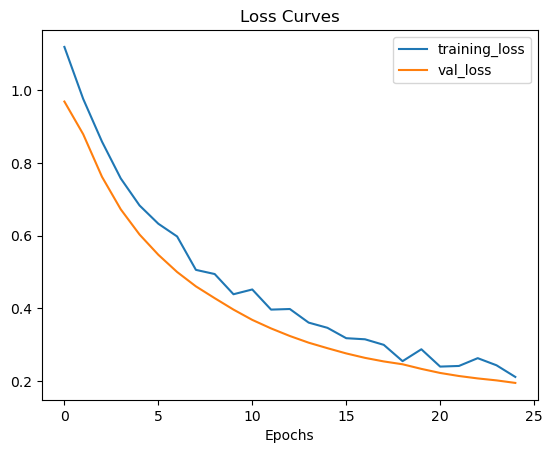

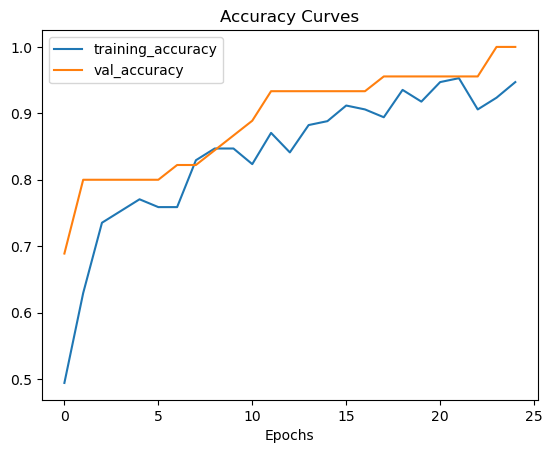

In [47]:
plot_loss_curves(history)

In [48]:
val_pred = model.predict(valid_data)
val_pred = val_pred.argmax(axis=1)
print(classification_report(val_pred, val_y))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



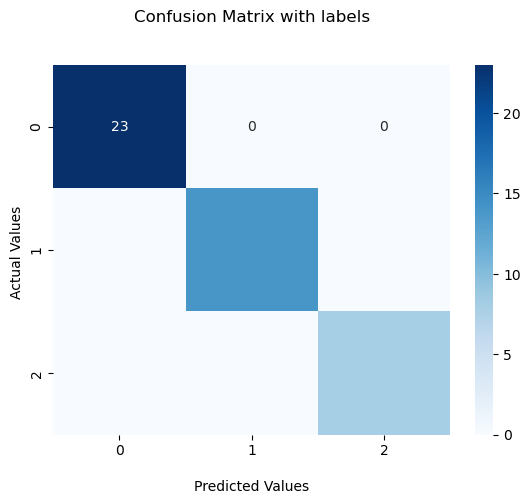

In [49]:
cfm_val = confusion_matrix(val_pred, val_y)
ax = sns.heatmap(cfm_val, annot=True, 
            cmap='Blues')

# Preparation for plotting confusion matrix
ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

# Display the visualization of the Confusion Matrix.
plt.show()

In [50]:
test_pred = model.predict(test_data)
test_pred = test_pred.argmax(axis=1)
print(classification_report(test_pred, test_y))

C:\Users\ajayk\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



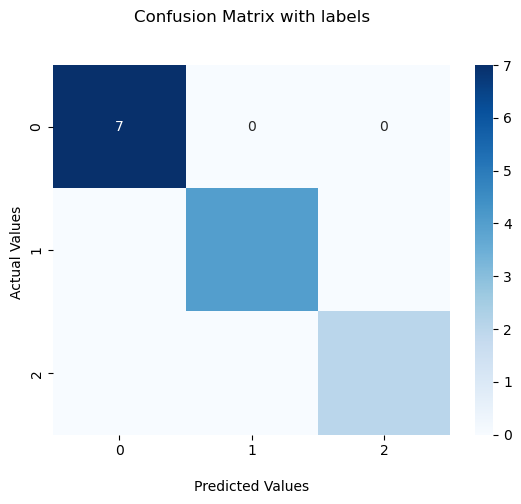

In [51]:
cfm_test = confusion_matrix(test_pred, test_y)
ax = sns.heatmap(cfm_test, annot=True, 
            cmap='Blues')

# Preparation for plotting confusion matrix
ax.set_title('Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

# Display the visualization of the Confusion Matrix.
plt.show()

In [52]:
model.save('my_model.keras')

In [53]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: No_entry


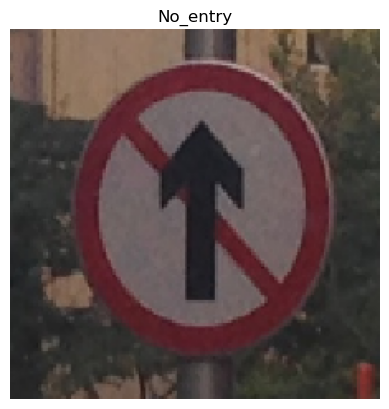

In [55]:
import matplotlib.pyplot as plt
from keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model
model = load_model('my_model.keras')

# Load the image
image_path = r"C:\Users\ajayk\Desktop\InnoProjects\Traffic_sign_detection_using_deep_learning\dataset\No_entry\010_1_0001.png"
image = image.load_img(image_path, target_size=(224, 224))

# Preprocess the image
img = np.array(image)
img = img / 255.0
img = img.reshape(1, 224, 224, 3)

# Predict the label
label = model.predict(img)

# Determine the predicted class
class_names = ['5_miles_speedlimit', 'No_entry', 'speedlimit_15']
predicted_class_index = np.argmax(label)
predicted_class = class_names[predicted_class_index]

# Print the predicted class
print("Predicted Class:", predicted_class)

# Display the image with the predicted label
plt.imshow(image)
plt.title(predicted_class)
plt.axis('off')
plt.show()
